Data standardization and normalization

1. Load the dataset that resulted from the "Processing categorical data" task.
2. We are planning to test the model using two different approaches to preparing numerical data for the model. The first one assumes normalization of the data. Perform data normalization. Use the appropriate class from the scikit-learn library or write a function using statistical methods from the Pandas library. Assign the data frame with normalized variables to the heart_data_normalized variable.
3. The second approach involves standardizing the data. Perform data standardization. Use the appropriate class from the scikit-learn library or write a function using statistical methods from the Pandas library. Assign the frame with the standardized variables to the heart_data_standardized variable.
4. Save both datasets to separate .csv files. When saving, omit the index column (the index argument in the method that allows you to save the file to .csv).

In [53]:
import pandas as pd

heart_encoded_df = pd.read_csv("data/heart_data_encoded.csv")
heart_encoded_df.head()

,age,restbp,chol,maxhr,oldpeak,slope,ca,thal_normal,thal_reversable,sex_male,chestpain_nonanginal,chestpain_nontypical,chestpain_typical,fbs_yes,exang_yes,restecg_1.0,restecg_2.0,ahd_yes
0,63.0,145.0,233.0,150.0,2.3,3.0,0.0,0,0,1,0,0,1,1,0,0,1,0
1,67.0,160.0,286.0,108.0,1.5,2.0,3.0,1,0,1,0,0,0,0,1,0,1,1
2,67.0,120.0,229.0,129.0,2.6,2.0,2.0,0,1,1,0,0,0,0,1,0,1,1
3,37.0,130.0,240.0,187.0,3.5,3.0,0.0,0,1,1,1,0,0,0,0,0,0,0
4,41.0,130.0,204.0,172.0,1.4,1.0,0.0,0,0,0,0,1,0,0,0,0,1,0


In [54]:
heart_encoded_df.describe()

,age,restbp,chol,maxhr,oldpeak,slope,ca,thal_normal,thal_reversable,sex_male,chestpain_nonanginal,chestpain_nontypical,chestpain_typical,fbs_yes,exang_yes,restecg_1.0,restecg_2.0,ahd_yes
count,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000
mean,54.451827,131.714286,246.857143,149.700997,1.043189,1.601329,0.667774,0.544850,0.392027,0.681063,0.282392,0.166113,0.076412,0.146179,0.325581,0.013289,0.488372,0.458472
std,9.067258,17.655729,51.860996,22.860817,1.163384,0.616872,0.935908,0.498814,0.489016,0.466841,0.450913,0.372802,0.266099,0.353874,0.469372,0.114700,0.500697,0.499102
min,29.000000,94.000000,126.000000,71.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,120.000000,211.000000,134.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,130.000000,240.000000,153.000000,0.800000,2.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,61.000000,140.000000,275.000000,166.000000,1.600000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
max,77.000000,200.000000,564.000000,202.000000,6.200000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [55]:
feature_cols = ["age", "restbp", "chol", "maxhr", "oldpeak", "slope", "ca"]
dummy_cols = [c for c in heart_encoded_df.columns if c not in feature_cols and c != "ahd_yes"]

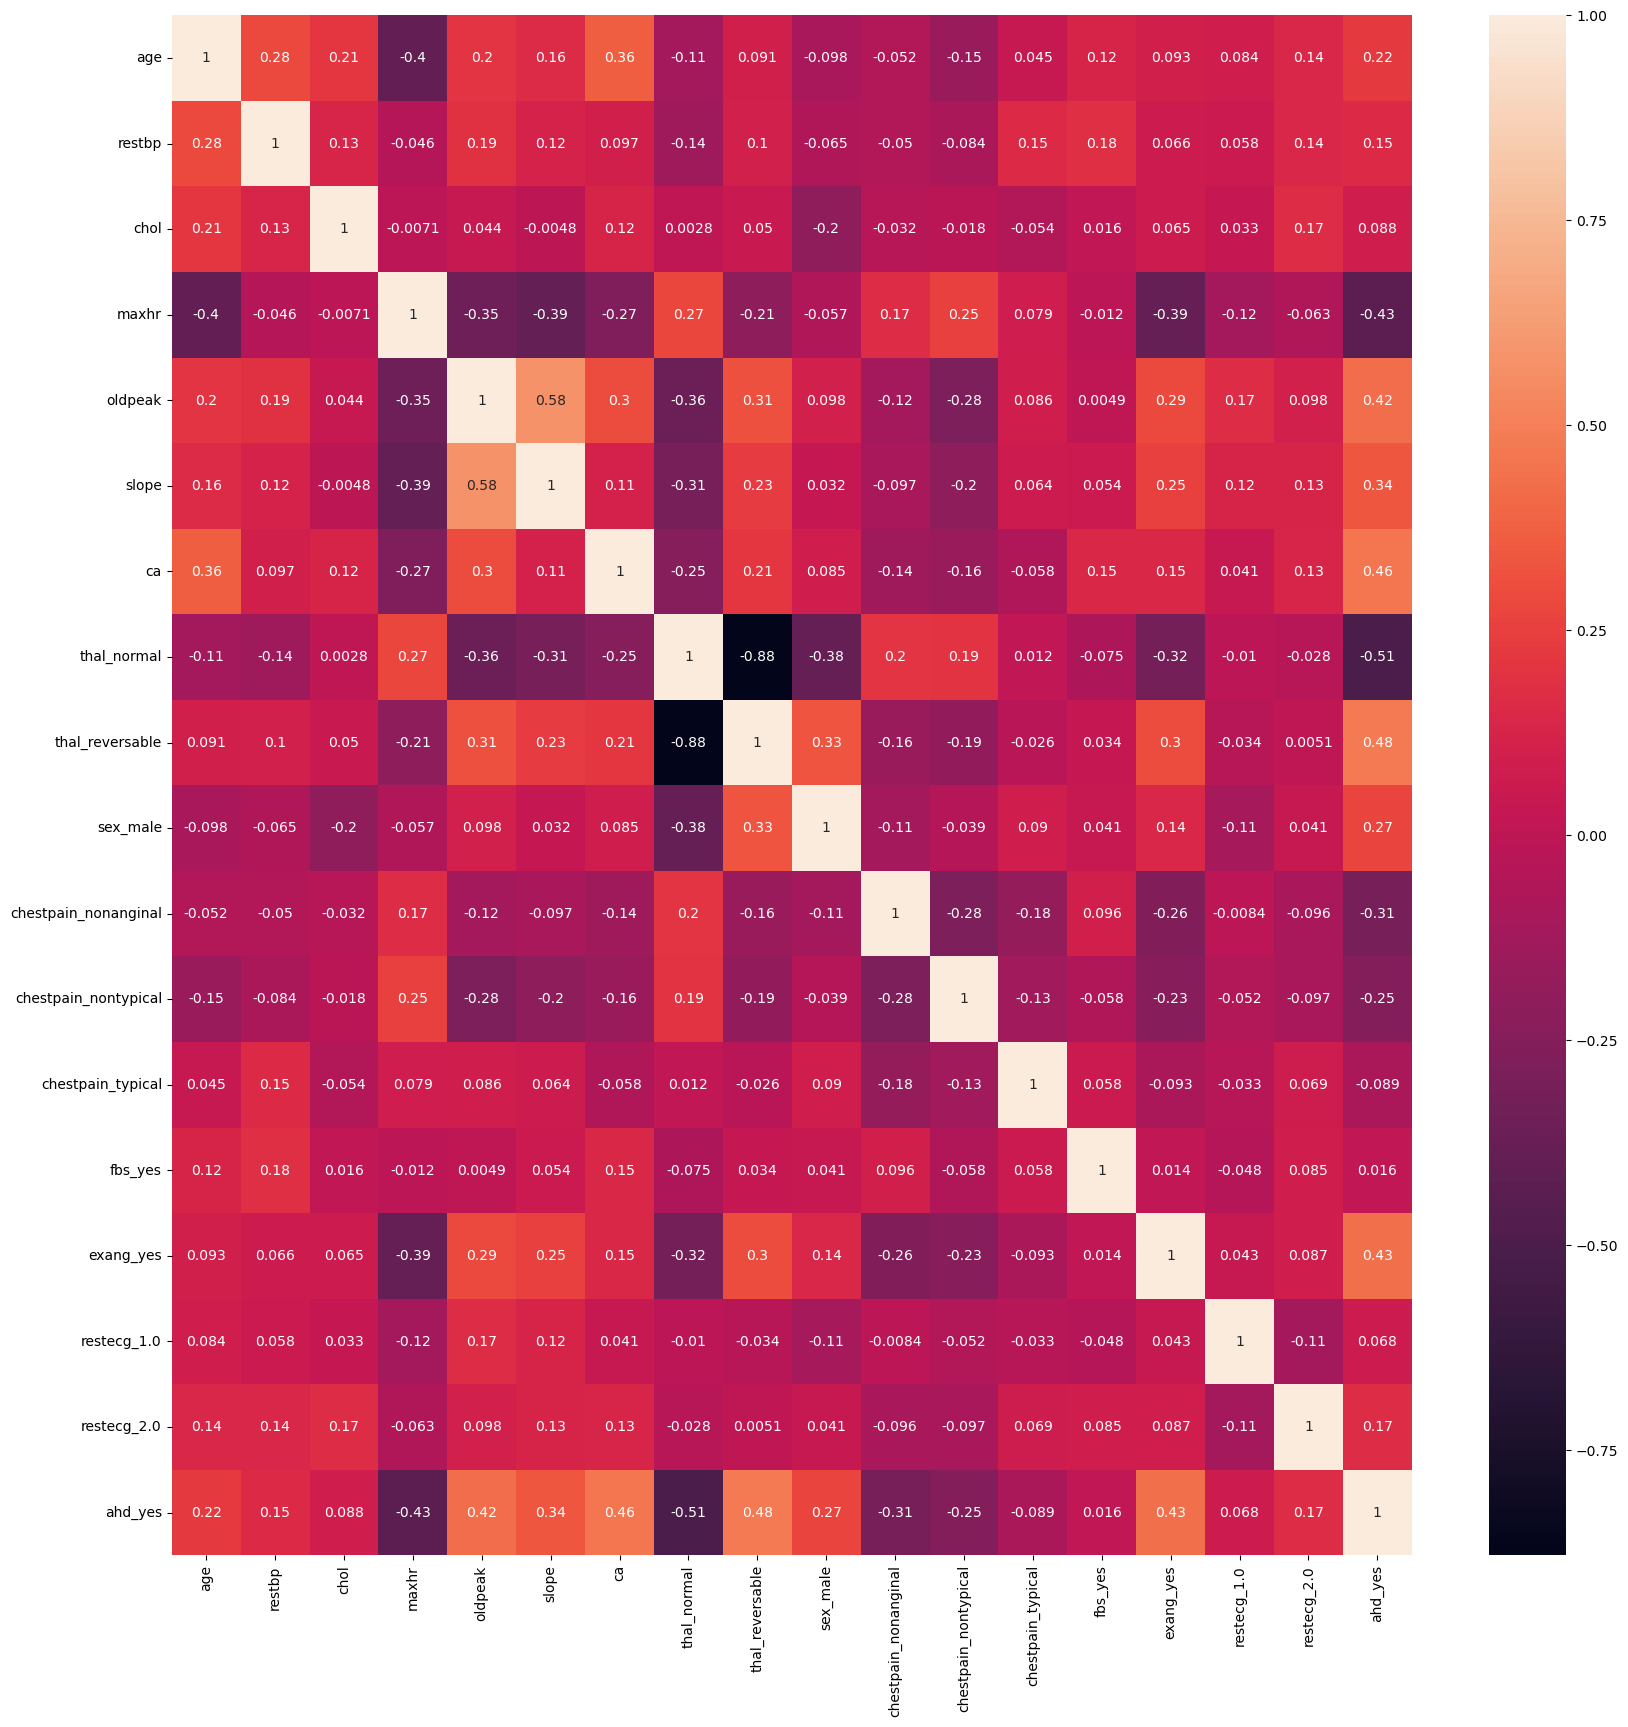

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = heart_encoded_df.corr()

plt.figure(figsize=(20, 20))
corr_plot = sns.heatmap(corr_matrix, annot=True)

In [57]:
# Normalize data using MinMaxScaler - scikit-learn
# normalize only the original numeric columns, never the already-encoded dummy columns.
from sklearn.preprocessing import MinMaxScaler

norm = MinMaxScaler()
heart_normalized_df = heart_encoded_df.copy()
heart_normalized_df[feature_cols] = norm.fit_transform(heart_normalized_df[feature_cols])
heart_normalized_df

,age,restbp,chol,maxhr,oldpeak,slope,ca,thal_normal,thal_reversable,sex_male,chestpain_nonanginal,chestpain_nontypical,chestpain_typical,fbs_yes,exang_yes,restecg_1.0,restecg_2.0,ahd_yes
0,0.708333,0.481132,0.244292,0.603053,0.370968,1.0,0.000000,0,0,1,0,0,1,1,0,0,1,0
1,0.791667,0.622642,0.365297,0.282443,0.241935,0.5,1.000000,1,0,1,0,0,0,0,1,0,1,1
2,0.791667,0.245283,0.235160,0.442748,0.419355,0.5,0.666667,0,1,1,0,0,0,0,1,0,1,1
3,0.166667,0.339623,0.260274,0.885496,0.564516,1.0,0.000000,0,1,1,1,0,0,0,0,0,0,0
4,0.250000,0.339623,0.178082,0.770992,0.225806,0.0,0.000000,0,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,0.333333,0.150943,0.315068,0.465649,0.193548,0.5,0.000000,0,1,1,0,0,1,0,0,0,0,1
297,0.812500,0.471698,0.152968,0.534351,0.548387,0.5,0.666667,0,1,1,0,0,0,1,0,0,0,1
298,0.583333,0.339623,0.011416,0.335878,0.193548,0.5,0.333333,0,1,1,0,0,0,0,1,0,0,1
299,0.583333,0.339623,0.251142,0.786260,0.000000,0.5,0.333333,1,0,0,0,1,0,0,0,0,1,1


In [58]:
heart_normalized_df.to_csv("data/heart_normalized_df.csv", index=False)
print("Saved")

Saved


In [59]:
# Standardize data using Standardscaler- scikit-learn
# Standardize only the original numeric columns, never the already-encoded dummy columns.

from sklearn.preprocessing import StandardScaler

stnd = StandardScaler()
heart_standardized_df = heart_encoded_df.copy()
heart_standardized_df[feature_cols] = stnd.fit_transform(heart_standardized_df[feature_cols])
heart_standardized_df


,age,restbp,chol,maxhr,oldpeak,slope,ca,thal_normal,thal_reversable,sex_male,chestpain_nonanginal,chestpain_nontypical,chestpain_typical,fbs_yes,exang_yes,restecg_1.0,restecg_2.0,ahd_yes
0,0.944322,0.753741,-0.267643,0.013101,1.082105,2.271135,-0.714692,0,0,1,0,0,1,1,0,0,1,0
1,1.386204,1.604738,0.756022,-1.827163,0.393311,0.647354,2.496088,1,0,1,0,0,0,0,1,0,1,1
2,1.386204,-0.664588,-0.344900,-0.907031,1.340403,0.647354,1.425828,0,1,1,0,0,0,0,1,0,1,1
3,-1.927913,-0.097257,-0.132442,1.634286,2.115297,2.271135,-0.714692,0,1,1,1,0,0,0,0,0,0,0
4,-1.486031,-0.097257,-0.827761,0.977049,0.307211,-0.976426,-0.714692,0,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,-1.044149,-1.231920,0.331104,-0.775584,0.135013,0.647354,-0.714692,0,1,1,0,0,1,0,0,0,0,1
297,1.496675,0.697007,-1.040220,-0.381241,2.029197,0.647354,1.425828,0,1,1,0,0,0,1,0,0,0,1
298,0.281498,-0.097257,-2.237714,-1.520452,0.135013,0.647354,0.355568,0,1,1,0,0,0,0,1,0,0,1
299,0.281498,-0.097257,-0.209699,1.064681,-0.898179,0.647354,0.355568,1,0,0,0,1,0,0,0,0,1,1


In [60]:
heart_standardized_df.to_csv("data/heart_standarized_df.csv", index=False)
print("Saved")

Saved
